In [2]:
import json
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
from matplotlib.transforms import blended_transform_factory

In [3]:
def load_all_data_from_json(file_path):
    with open(file_path, "r") as file:
        data = json.load(file)
    return data

In [4]:
def load_values_from_json_without_normalization(file_path):
    with open(file_path, "r") as file:
        data_org = json.load(file)
    return list(data_org.values())
    #return [v for k, v in data_org.items() if "normalized" in k]

In [5]:
def load_values_from_json(file_path):
    with open(file_path, "r") as file:
        data_org = json.load(file)
    #return list(data_org.values())
    return [v for k, v in data_org.items() if "normalized" in k]

In [6]:
def get_files_with_cd(file_path, data_values, th):
    all_data = load_all_data_from_json(file_path)
    threshold = th
    keys_above_threshold = [key for key, value in all_data.items() if value > threshold]
    
    print(f"\nObjects whith Chamfer > {threshold}:")
    for key in keys_above_threshold:
        print(key)

    # Total number of files
    print(f"\nNumber of objects with Chamfer > {threshold}: {len(keys_above_threshold)} of {len(data_values)}")

In [7]:
def generate_histogram(data, bins, alpha, title, class_labels, means, colors):
    bins = 50
    plt.figure(figsize=(8, 4))

    all_data = np.concatenate(data)
    bin_edges = np.histogram_bin_edges(all_data, bins=bins)

    for i in range(len(data)):
        plt.hist(data[i], bins=bin_edges, alpha=alpha, color=colors[i], label=class_labels[i])
    for i in range(len(data)):    
        plt.axvline(means[i], color=colors[i], linestyle='--', linewidth=1.5, label=f"{class_labels[i]} Mean: {round(means[i], 3)}")

    # Add legend and labels
    plt.legend()
    plt.xlabel('Chamfer Distance Results')
    plt.ylabel('Frequency')
    plt.title(title)
    plt.show()

In [8]:
mpl.rcParams.update({
    'svg.fonttype': 'none',        # texto editable en SVG
    'pdf.fonttype': 42,            # texto como texto, no curvas
    'font.family': 'STIXGeneral',  # "Times-like" portátil
    'mathtext.fontset': 'stix'
})

In [9]:
def generate_histogram_and_save(data, g_class, bins, alpha, title, class_labels, means, colors, output_path):
    
    bins = 50
    plt.figure(figsize=(8, 5.3))

    all_data = np.concatenate(data)
    bin_edges = np.histogram_bin_edges(all_data, bins=bins)

    for i in range(len(data)):
        plt.hist(data[i], bins=bin_edges, alpha=alpha, color=colors[i], label=class_labels[i])
    for i in range(len(data)):    
        plt.axvline(means[i], color=colors[i], linestyle='--', linewidth=1.8, label=f"{class_labels[i]} Mean: {round(means[i], 3)}")
    
    # Set x-axis limits
    """ if g_class == 'chair':
        plt.xlim(0.000, 0.03)
        #plt.xticks(np.arange(0.0, 0.81, 0.09))
    else:
        plt.xlim(0.000, 0.03) """

    #plt.ylim(-0.01, 1000)

    # Add legend and labels
    plt.legend(frameon=True, framealpha=1.0)
    plt.xlabel('Chamfer Distance Results')
    plt.ylabel('Frequency')
    plt.title(title, pad=12 )
    plt.tight_layout()

    pdf_path = output_path.replace('.svg', '.pdf')
    plt.savefig(pdf_path, format='pdf', transparent=False)
    plt.show()
    plt.close()
    print(f"✅ Histograma guardado en: {output_path}")

In [10]:
def generate_histogram_and_save_with_means_old(data, bins, alpha, title, class_labels, means, colors, output_path, mean_labels=None):
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    })

    fig, ax = plt.subplots(figsize=(7.5, 4.5), facecolor="white")

    all_data = np.concatenate(data)
    bin_edges = np.histogram_bin_edges(all_data, bins=bins)

    # Histogramas más limpios
    for i in range(len(data)):
        ax.hist(
            data[i],
            bins=bin_edges,
            alpha=alpha,
            color=colors[i],
            edgecolor="none",
            histtype="stepfilled"
        )

    # Límite Y para posicionar las etiquetas
    ymax = ax.get_ylim()[1]

    # Pequeños offsets verticales para evitar que se monten
    y_positions = [0.92, 0.84, 0.76]

    for i in range(len(data)):
        # Línea vertical de la media
        ax.axvline(
            means[i],
            color=colors[i],
            linestyle="--",
            linewidth=1.8,
            zorder=3
        )

        # Etiqueta con fondo blanco
        ax.text(
            means[i],
            ymax * y_positions[i],
            mean_labels[i] + " = " + f"{means[i]:.4f}",
            color=colors[i],
            fontsize=12,
            ha="center",
            va="center",
            bbox=dict(
                boxstyle="round,pad=0.20",
                facecolor="white",
                edgecolor="none",
                alpha=0.95
            ),
            zorder=4
        )

    # Ejes
    ax.set_xlabel("Chamfer Distance")
    ax.set_ylabel("Frequency")
    ax.set_title(title, pad=12)

    # Estética más limpia
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Si quieres una grilla muy suave
    ax.grid(axis="y", alpha=0.12, linewidth=0.7)

    # Márgenes finos
    fig.subplots_adjust(top=0.88, bottom=0.16, left=0.10, right=0.97)

    pdf_path = output_path.replace(".svg", ".pdf")
    plt.savefig(pdf_path, format="pdf", transparent=False, bbox_inches="tight", pad_inches=0.03)
    plt.show()
    plt.close()

    print(f"✅ Histograma guardado en: {output_path}")

In [11]:
def generate_histogram_and_save_with_means(
    data,
    bins,
    alpha,
    title,
    class_labels,
    means,
    colors,
    output_path,
    mean_labels=None
):
    import numpy as np
    import matplotlib.pyplot as plt

    # =========================================================
    # 1) ESTILO GENERAL PARA PAPER
    # =========================================================
    text_col = "#0b1f3a"
    axis_col = "#5f6f7a"
    grid_col = "#d7e0e8"

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],

        # Tamaños aumentados para que no se vean pequeños en LaTeX
        "font.size": 18,
        "axes.titlesize": 20,
        "axes.labelsize": 20,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 15,

        "figure.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.facecolor": "white",

        "text.color": text_col,
        "axes.labelcolor": text_col,
        "xtick.color": text_col,
        "ytick.color": text_col,

        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    if mean_labels is None:
        mean_labels = class_labels

    # =========================================================
    # 2) FIGURA
    # =========================================================
    fig, ax = plt.subplots(figsize=(9.2, 5.6), facecolor="white")

    all_data = np.concatenate(data)
    bin_edges = np.histogram_bin_edges(all_data, bins=bins)

    # =========================================================
    # 3) HISTOGRAMAS
    # =========================================================
    for i in range(len(data)):
        ax.hist(
            data[i],
            bins=bin_edges,
            alpha=alpha,
            color=colors[i],
            edgecolor="white",
            linewidth=0.35,
            histtype="stepfilled",
            label=class_labels[i],
            zorder=2
        )

    # =========================================================
    # 4) LÍNEAS DE MEDIA
    # =========================================================
    ymax = ax.get_ylim()[1]

    # Posiciones verticales más separadas para evitar superposición
    base_positions = [0.92, 0.81, 0.70, 0.59, 0.48]

    for i in range(len(data)):
        y_pos = base_positions[i] if i < len(base_positions) else 0.92 - i * 0.10

        ax.axvline(
            means[i],
            color=colors[i],
            linestyle="--",
            linewidth=2.3,
            alpha=0.95,
            zorder=4
        )

        ax.text(
            means[i],
            ymax * y_pos,
            f"{mean_labels[i]} = {means[i]:.4f}",
            color=colors[i],
            fontsize=16,
            fontweight="bold",
            ha="center",
            va="center",
            bbox=dict(
                boxstyle="round,pad=0.24",
                facecolor="white",
                edgecolor=colors[i],
                linewidth=0.8,
                alpha=0.96
            ),
            zorder=5
        )

    # =========================================================
    # 5) EJES Y TÍTULO
    # =========================================================
    ax.set_xlabel("NSCD", labelpad=10)
    ax.set_ylabel("Frequency", labelpad=10)

    ax.set_title(
        title,
        pad=14,
        loc="center",
        x=0.44
    )

    # =========================================================
    # 6) LEYENDA
    # =========================================================
    """ legend = ax.legend(
        loc="upper right",
        frameon=True,
        fancybox=False,
        borderpad=0.45,
        handlelength=1.7,
        labelspacing=0.35
    )

    legend.get_frame().set_facecolor("white")
    legend.get_frame().set_alpha(0.95)
    legend.get_frame().set_edgecolor("#c9d3dc")
    legend.get_frame().set_linewidth(0.8) """

    # =========================================================
    # 7) ESTÉTICA GENERAL
    # =========================================================
    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.75,
        color=grid_col,
        alpha=0.70,
        zorder=0
    )

    ax.set_axisbelow(True)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(axis_col)
        ax.spines[spine].set_linewidth(1.0)

    # Más espacio para título, ejes y etiquetas
    fig.subplots_adjust(
        top=0.88,
        bottom=0.17,
        left=0.13,
        right=0.96
    )

    # =========================================================
    # 8) GUARDADO
    # =========================================================
    if output_path.lower().endswith(".svg"):
        pdf_path = output_path[:-4] + ".pdf"

        plt.savefig(
            pdf_path,
            format="pdf",
            transparent=False,
            bbox_inches="tight",
            pad_inches=0.06
        )

        plt.savefig(
            output_path,
            format="svg",
            transparent=False,
            bbox_inches="tight",
            pad_inches=0.06
        )

        print(f"✅ Saved PDF: {pdf_path}")
        print(f"✅ Saved SVG: {output_path}")

    else:
        plt.savefig(
            output_path,
            transparent=False,
            bbox_inches="tight",
            pad_inches=0.06,
            dpi=400
        )

        print(f"✅ Saved figure: {output_path}")

    plt.show()
    plt.close()

In [12]:
def generate_heatmap_and_save_old(results, models, title, output_path, threshold_line=True):
    # =========================================================
    # 2) HISTOGRAMAS CON BINS COMUNES
    # =========================================================
    all_values = np.concatenate([np.asarray(results[m], dtype=float) for m in models])

    for m in models:
        for i in results[m]:
            if i >= 0.042:
                print(m, i)

    n_bins = 30
    bins = np.linspace(all_values.min(), all_values.max(), n_bins + 1)

    heatmap_data = []
    means = []

    for model in models:
        values = np.asarray(results[model], dtype=float)
        counts, _ = np.histogram(values, bins=bins)
        heatmap_data.append(counts)
        means.append(values.mean())

    heatmap_data = np.array(heatmap_data)
    means = np.array(means)

    # =========================================================
    # 3) THRESHOLD GLOBAL
    # =========================================================
    s_model_means = [means[i] for i, m in enumerate(models) if m.startswith("S-")]
    original_means = [means[i] for i, m in enumerate(models)
                    if (not m.startswith("S-")) and m != "ShapeNet"]

    threshold = means[0] #(np.mean(s_model_means) + np.mean(original_means)) / 2

    print(f"Media grupo S-models: {np.mean(s_model_means):.4f}")
    print(f"Media grupo originales: {np.mean(original_means):.4f}")
    print(f"Threshold: {threshold:.4f}")

    # =========================================================
    # 4) PALETA Y ESTILO
    # SOLO EL INTERIOR DEL HEATMAP TENDRÁ COLOR
    # =========================================================
    base_teal = "#0f2f33"
    panel_bg = "#f4f8f9"
    text_col = "#0b1f3a"
    line_col = "#1d4e89"

    teal_cmap = LinearSegmentedColormap.from_list(
        "teal_custom",
        [panel_bg, "#c7dcdf", "#8fbfc4", "#4a9aa4", base_teal]#["#f7fcf0", "#ccebc5", "#7bccc4", "#2b8cbe", "#084081"]#[panel_bg, "#d6e4f0", "#9fbfda", "#4f8fc0", base_teal]
    )

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 11,
        "figure.facecolor": "white",   # FUERA de la figura en blanco
        "savefig.facecolor": "white",  # al guardar también blanco
        "axes.facecolor": "white",
        "text.color": text_col,
        "axes.labelcolor": text_col,
        "xtick.color": text_col,
        "ytick.color": text_col
    })

    # =========================================================
    # 5) FIGURA
    # =========================================================
    fig = plt.figure(figsize=(8, 5), facecolor="white")
    gs = fig.add_gridspec(
        1, 3,
        width_ratios=[18, 2.2, 0.55],
        wspace=0.08
    )

    ax = fig.add_subplot(gs[0, 0])
    ax_mean = fig.add_subplot(gs[0, 1], sharey=ax)
    cax = fig.add_subplot(gs[0, 2])

    # SOLO el heatmap interno lleva color
    ax.set_facecolor(panel_bg)

    # Mean CD y colorbar quedan blancos
    ax_mean.set_facecolor("white")
    cax.set_facecolor("white")

    # Normalización suave
    vmax = np.percentile(heatmap_data, 99.5)
    norm = PowerNorm(gamma=0.9, vmin=0, vmax=vmax)

    # =========================================================
    # 6) HEATMAP
    # =========================================================
    x_edges = bins
    y_edges = np.arange(len(models) + 1)

    mesh = ax.pcolormesh(
        x_edges,
        y_edges,
        heatmap_data,
        cmap=teal_cmap,
        norm=norm,
        shading="flat",
        edgecolors="none"
    )

    ax.set_ylim(0, len(models))
    ax.invert_yaxis()

    y_centers = np.arange(len(models)) + 0.5
    ax.set_yticks(y_centers)
    ax.set_yticklabels(models)

    # Línea de threshold
    if threshold_line == True:
        ax.axvline(
            threshold,
            color=line_col,
            linestyle=(0, (4, 3)),
            linewidth=1.2,
            alpha=0.95,
            zorder=2
        )

    # Marcas de media dentro del heatmap
    ax.scatter(
        means,
        y_centers,
        s=28,
        color=base_teal,
        edgecolor="#f7fbfc",
        linewidth=0.8,
        zorder=3
    )

    # Separadores horizontales suaves
    for y in range(1, len(models)):
        ax.hlines(y, bins[0], bins[-1], color="#f7fbfc", linewidth=0.8, alpha=0.45)

    # Bordes
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.set_title(title, pad=14, color=text_col)
    ax.set_xlabel("Chamfer Distance Results", labelpad=14)
    ax.set_ylabel("")

    # =========================================================
    # 7) COLUMNA DE MEDIAS
    # =========================================================
    ax_mean.set_xlim(0, 1)
    ax_mean.set_ylim(0, len(models))
    ax_mean.invert_yaxis()
    ax_mean.axis("off")

    ax_mean.text(
        0.06, -0.20,
        "Mean CD",
        ha="left", va="bottom",
        fontsize=11.5, fontweight="bold",
        color=base_teal
    )

    for y, mean_val in zip(y_centers, means):
        ax_mean.plot(
            [0.10, 0.10],
            [y - 0.14, y + 0.14],
            color=line_col,
            linewidth=1.6,
            solid_capstyle="round",
            zorder=2
        )

        ax_mean.scatter(
            0.10, y,
            s=36,
            color=base_teal,
            edgecolor="#f7fbfc",
            linewidth=0.7,
            zorder=3
        )

        ax_mean.text(
            0.24, y,
            f"{mean_val:.4f}",
            ha="left", va="center",
            fontsize=10.5,
            family="monospace",
            color=text_col
        )

    # =========================================================
    # 8) COLORBAR
    # =========================================================
    cbar = fig.colorbar(mesh, cax=cax)
    cbar.set_label("Frequency", color=text_col, labelpad=8)
    cbar.ax.tick_params(colors=text_col)
    cbar.outline.set_linewidth(0.6)

    # =========================================================
    # 9) AJUSTE FINAL
    # =========================================================
    pdf_path = output_path.replace('.svg', '.pdf')

    fig.subplots_adjust(
        top=0.88,
        bottom=0.20,
        left=0.12,
        right=0.95
    )

    plt.savefig(pdf_path, format='pdf', transparent=False, bbox_inches='tight', pad_inches=0.06)
    plt.show()
    plt.close()
    print(f"✅ Histograma guardado en: {output_path}")

In [13]:
def generate_heatmap_and_save(
    results,
    models,
    title,
    output_path,
    threshold_line=True,
    show_title=False,
    show_colorbar=True
):
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import LinearSegmentedColormap, PowerNorm
    from matplotlib.ticker import MaxNLocator

    # =========================================================
    # 1) HISTOGRAMAS CON BINS COMUNES
    # =========================================================
    all_values = np.concatenate([
        np.asarray(results[m], dtype=float) for m in models
    ])

    n_bins = 34
    bins = np.linspace(all_values.min(), all_values.max(), n_bins + 1)

    heatmap_data = []
    means = []

    for model in models:
        values = np.asarray(results[model], dtype=float)
        counts, _ = np.histogram(values, bins=bins)
        heatmap_data.append(counts)
        means.append(values.mean())

    heatmap_data = np.array(heatmap_data)
    means = np.array(means)

    threshold = means[0]

    # =========================================================
    # 2) ESTILO
    # =========================================================
    base_teal = "#0f2f33"
    panel_bg = "#f4f8f9"
    text_col = "#0b1f3a"
    axis_col = "#5f6f7a"
    line_col = "#1d4e89"

    mean_point_color = "#3f4a5a"
    mean_point_edge = "#ffffff"

    teal_cmap = LinearSegmentedColormap.from_list(
        "teal_custom",
        [
            panel_bg,
            "#c7dcdf",
            "#8fbfc4",
            "#4a9aa4",
            base_teal
        ]
    )

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],

        "font.size": 18,
        "axes.titlesize": 18,
        "axes.labelsize": 18,
        "xtick.labelsize": 14,
        "ytick.labelsize": 15,

        "figure.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.facecolor": "white",

        "text.color": text_col,
        "axes.labelcolor": text_col,
        "xtick.color": text_col,
        "ytick.color": text_col,

        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    # =========================================================
    # 3) FIGURA MÁS ALTA Y HEATMAP MÁS ANCHO
    # =========================================================
    if show_colorbar:
        fig = plt.figure(figsize=(7.2, 4.85), facecolor="white")

        gs = fig.add_gridspec(
            1, 4,
            # heatmap | Mean CD | espacio mínimo | colorbar
            width_ratios=[53.0, 14, 0, 1.5],
            wspace=0.045
        )

        ax = fig.add_subplot(gs[0, 0])

        # MODIFICADO:
        # No usar sharey=ax para evitar que Mean CD herede
        # los nombres de los modelos.
        ax_mean = fig.add_subplot(gs[0, 1])

        ax_space = fig.add_subplot(gs[0, 2])
        cax = fig.add_subplot(gs[0, 3])

        ax_space.axis("off")

    else:
        fig = plt.figure(figsize=(5.65, 4.25), facecolor="white")

        gs = fig.add_gridspec(
            1, 2,
            width_ratios=[23.0, 4.6],
            wspace=0.08
        )

        ax = fig.add_subplot(gs[0, 0])

        # MODIFICADO:
        # No usar sharey=ax.
        ax_mean = fig.add_subplot(gs[0, 1])

        cax = None

    ax.set_facecolor(panel_bg)
    ax_mean.set_facecolor("white")

    # =========================================================
    # 4) NORMALIZACIÓN
    # =========================================================
    vmax = np.percentile(heatmap_data, 99.5)

    if vmax <= 0:
        vmax = heatmap_data.max() if heatmap_data.max() > 0 else 1

    norm = PowerNorm(
        gamma=0.9,
        vmin=0,
        vmax=vmax
    )

    # =========================================================
    # 5) HEATMAP
    # =========================================================
    x_edges = bins
    y_edges = np.arange(len(models) + 1)

    mesh = ax.pcolormesh(
        x_edges,
        y_edges,
        heatmap_data,
        cmap=teal_cmap,
        norm=norm,
        shading="flat",
        edgecolors="none"
    )

    ax.set_ylim(0, len(models))
    ax.invert_yaxis()

    y_centers = np.arange(len(models)) + 0.5
    ax.set_yticks(y_centers)
    ax.set_yticklabels(models, fontsize=15)

    if threshold_line:
        ax.axvline(
            threshold,
            color=line_col,
            linestyle=(0, (4, 3)),
            linewidth=1.8,
            alpha=0.95,
            zorder=3
        )

    ax.scatter(
        means,
        y_centers,
        s=48,
        color=mean_point_color,
        edgecolor=mean_point_edge,
        linewidth=1.0,
        zorder=5
    )

    for y in range(1, len(models)):
        ax.hlines(
            y,
            bins[0],
            bins[-1],
            color="#f7fbfc",
            linewidth=0.9,
            alpha=0.50,
            zorder=2
        )

    # =========================================================
    # 6) EJES
    # =========================================================
    ax.set_xlabel(
        "NSCD",
        labelpad=9,
        fontsize=17
    )

    ax.set_ylabel("")
    ax.tick_params(axis="x", labelsize=14)
    ax.tick_params(axis="y", labelsize=15)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))

    if show_title:
        ax.set_title(
            title,
            pad=9,
            fontsize=17,
            color=text_col
        )

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(axis_col)
        ax.spines[spine].set_linewidth(0.9)

    # =========================================================
    # 7) COLUMNA MEAN CD SIN TEXTOS DE MODELOS
    # =========================================================
    ax_mean.set_xlim(0, 1)
    ax_mean.set_ylim(ax.get_ylim())

    # Apagar por completo ticks, labels y bordes
    ax_mean.set_xticks([])
    ax_mean.set_yticks([])
    ax_mean.tick_params(
        left=False,
        right=False,
        labelleft=False,
        labelright=False,
        bottom=False,
        top=False,
        labelbottom=False,
        labeltop=False
    )

    for spine in ax_mean.spines.values():
        spine.set_visible(False)

    ax_mean.set_facecolor("white")

    # x en coordenadas del eje, y en coordenadas de datos
    # Esto alinea punto, número y encabezado de forma estable
    mean_transform = blended_transform_factory(ax_mean.transAxes, ax_mean.transData)

    dot_x = 0.12
    value_x = 0.25
    header_x = 0.50

    ax_mean.text(
        header_x,
        1.025,
        "Mean NSCD",
        transform=ax_mean.transAxes,
        ha="center",
        va="bottom",
        fontsize=16.5,
        fontweight="bold",
        color=text_col,
        clip_on=False
    )

    for y, mean_val in zip(y_centers, means):
        ax_mean.scatter(
            dot_x,
            y,
            s=38,
            color=mean_point_color,
            edgecolor=mean_point_edge,
            linewidth=0.85,
            transform=mean_transform,
            zorder=4
        )

        ax_mean.text(
            value_x,
            y,
            f"{mean_val:.4f}",
            ha="left",
            va="center",
            fontsize=15.5,
            family="monospace",
            color=text_col,
            transform=mean_transform
        )

    # =========================================================
    # 8) COLORBAR MÁS SEPARADA
    # =========================================================
    if show_colorbar:
        cbar = fig.colorbar(mesh, cax=cax)

        cbar.set_label(
            "Frequency",
            color=text_col,
            labelpad=9,
            fontsize=14
        )

        cbar.ax.tick_params(
            colors=text_col,
            labelsize=13,
            width=0.7,
            length=3
        )

        cbar.outline.set_linewidth(0.6)
        cbar.outline.set_edgecolor(axis_col)

    # =========================================================
    # 9) AJUSTE FINAL
    # =========================================================
    fig.subplots_adjust(
        top=0.91 if not show_title else 0.84,
        bottom=0.18,
        left=0.13,
        right=0.98
    )

    # =========================================================
    # 10) GUARDADO
    # =========================================================
    if output_path.lower().endswith(".svg"):
        pdf_path = output_path[:-4] + ".pdf"

        plt.savefig(
            pdf_path,
            format="pdf",
            transparent=False,
            bbox_inches="tight",
            pad_inches=0.04
        )

        plt.savefig(
            output_path,
            format="svg",
            transparent=False,
            bbox_inches="tight",
            pad_inches=0.04
        )

        print(f"✅ Saved PDF: {pdf_path}")
        print(f"✅ Saved SVG: {output_path}")

    else:
        plt.savefig(
            output_path,
            transparent=False,
            bbox_inches="tight",
            pad_inches=0.04,
            dpi=400
        )

        print(f"✅ Saved figure: {output_path}")

    plt.show()
    plt.close()

    return heatmap_data, means

# GCA

## Airplane

0.02317647818310092
0.023392110668139947


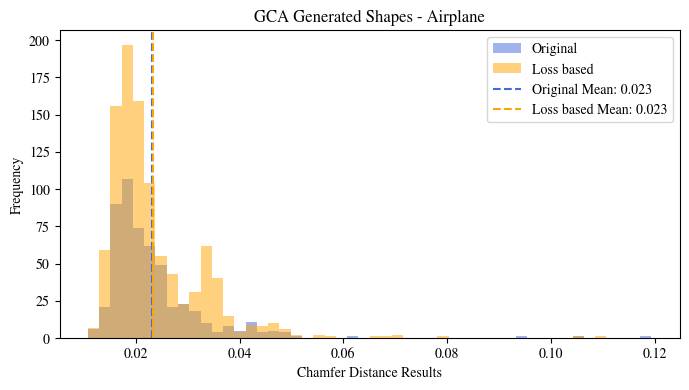

In [14]:
file_path = "/home/isipiran/Symmetrization-of-3D-Generative-Models/Symmetry_Measurement_Protocol/json_files/original_airplane_100.json"
gca_airplane_data = load_values_from_json(file_path)
gca_original_airplane_mean = np.mean(gca_airplane_data)
print(gca_original_airplane_mean)

file_path = "/home/isipiran/Symmetrization-of-3D-Generative-Models/Symmetry_Measurement_Protocol/json_files/symmetry_lossbased_airplane_100.json"
gca_symmetry_airplane_data = load_values_from_json(file_path)
gca_symmetry_airplane_mean = np.mean(gca_symmetry_airplane_data)
print(gca_symmetry_airplane_mean)

data = [gca_airplane_data, gca_symmetry_airplane_data]
class_labels = ["Original", "Loss based", "Rule based"]
means = [gca_original_airplane_mean, gca_symmetry_airplane_mean]
colors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="GCA Generated Shapes - Airplane", class_labels=class_labels, means=means, colors=colors)

## Car

0.030751298188188
0.03299937528538727


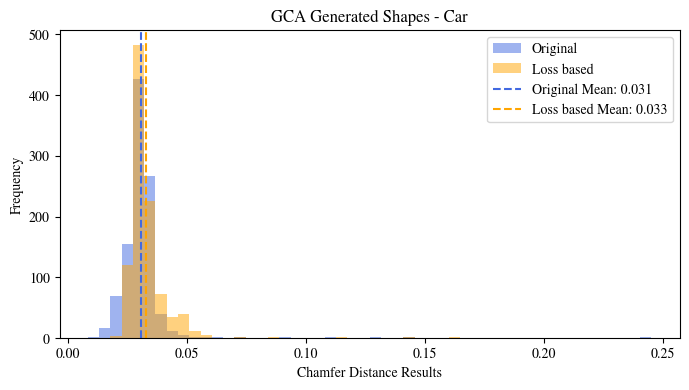

In [15]:
file_path = "/home/isipiran/Symmetrization-of-3D-Generative-Models/Symmetry_Measurement_Protocol/json_files/original_car_100_r2.json"
gca_car_data = load_values_from_json(file_path)
gca_original_car_mean = np.mean(gca_car_data)
print(gca_original_car_mean)

file_path = "/home/isipiran/Symmetrization-of-3D-Generative-Models/Symmetry_Measurement_Protocol/json_files/symmetry_lossbased_car_100_r2.json"
gca_symmetry_car_data = load_values_from_json(file_path)
gca_symmetry_car_mean = np.mean(gca_symmetry_car_data)
print(gca_symmetry_car_mean)

data = [gca_car_data, gca_symmetry_car_data]
class_labels = ["Original", "Loss based", "Rule based"]
means = [gca_original_car_mean, gca_symmetry_car_mean]
colors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="GCA Generated Shapes - Car", class_labels=class_labels, means=means, colors=colors)

## Chair

0.06271065348530247
0.04438572640869256


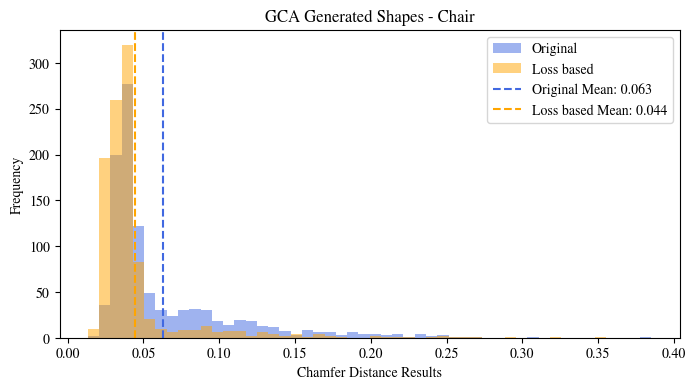

In [16]:
file_path = "/home/isipiran/Symmetrization-of-3D-Generative-Models/Symmetry_Measurement_Protocol/json_files/original_chair_100.json"
gca_chair_data = load_values_from_json(file_path)
gca_original_chair_mean = np.mean(gca_chair_data)
print(gca_original_chair_mean)

file_path = "/home/isipiran/Symmetrization-of-3D-Generative-Models/Symmetry_Measurement_Protocol/json_files/symmetry_lossbased_chair_100.json"
gca_symmetry_chair_data = load_values_from_json(file_path)
gca_symmetry_chair_mean = np.mean(gca_symmetry_chair_data)
print(gca_symmetry_chair_mean)

data = [gca_chair_data, gca_symmetry_chair_data]
class_labels = ["Original", "Loss based", "Rule based"]
means = [gca_original_chair_mean, gca_symmetry_chair_mean]
colors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="GCA Generated Shapes - Chair", class_labels=class_labels, means=means, colors=colors)

## Bowl

0.02955731658637699
0.02909696210827618


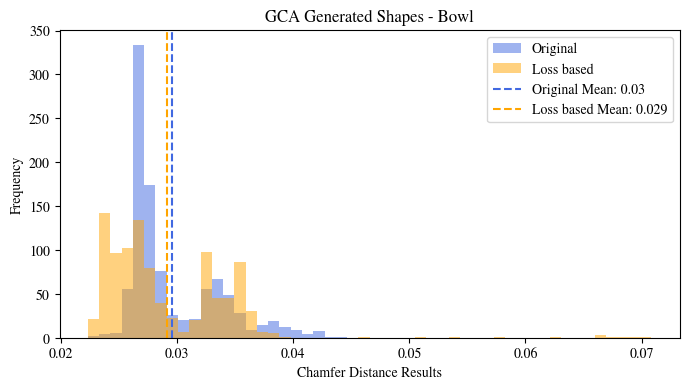

In [17]:
file_path = "/home/isipiran/Symmetrization-of-3D-Generative-Models/Symmetry_Measurement_Protocol/json_files/original_bowl_30.json"
gca_bowl_data = load_values_from_json(file_path)
gca_original_bowl_mean = np.mean(gca_bowl_data)
print(gca_original_bowl_mean)

file_path = "/home/isipiran/Symmetrization-of-3D-Generative-Models/Symmetry_Measurement_Protocol/json_files/symmetry_lossbased_bowl_30.json"
gca_symmetry_bowl_data = load_values_from_json(file_path)
gca_symmetry_bowl_mean = np.mean(gca_symmetry_bowl_data)
print(gca_symmetry_bowl_mean)

data = [gca_bowl_data, gca_symmetry_bowl_data]
class_labels = ["Original", "Loss based", "Rule based"]
means = [gca_original_bowl_mean, gca_symmetry_bowl_mean]
colors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="GCA Generated Shapes - Bowl", class_labels=class_labels, means=means, colors=colors)

### Symmetria

0.017336738785060056


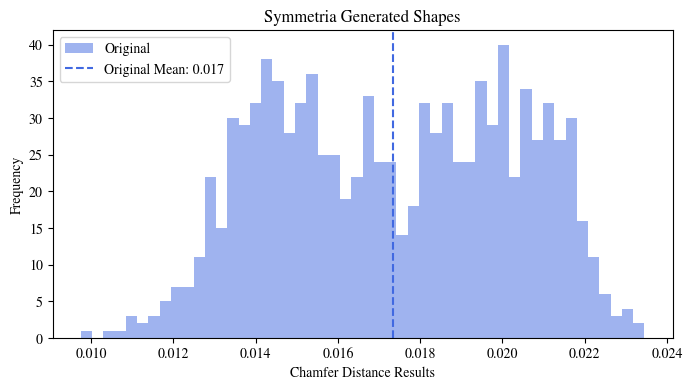

In [24]:
file_path = "/home/isipiran/Symmetrization-of-3D-Generative-Models/Symmetry_Measurement_Protocol/json_files/symmetry_symmetria.json"
symmetria_bowl_data = load_values_from_json(file_path)
symmetria_original_bowl_mean = np.mean(symmetria_bowl_data)
print(symmetria_original_bowl_mean)

data = [symmetria_bowl_data]
class_labels = ["Original"]
means = [symmetria_original_bowl_mean]
colors = ["royalblue"]

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetria Generated Shapes", class_labels=class_labels, means=means, colors=colors)